# Milestone 1 - Data Vizualization

### Ahmed Chaouachi (346447)
### Shin Urech (327245)
### Joyti Goel (325374)



## Dataset

### Primary Dataset

Primary Dataset: **Last.fm UK User Graph Dataset**

Source: **Zenodo** (`10.5281/zenodo.10694369`)

Published: **February 2024 — University of Pisa / CNR**

The dataset consists of four interconnected files:

| File | Contents |
| --- | --- |
| `network` | 75,969 nodes (users) and 389,639 undirected friendship edges |
| `UsersData_anonymized` | Per-user attributes: gender, age, country |
| `ArtistTags` | Artists mapped to musical genres, weighted by user assignment |
| `ArtistsMap` | Artist names mapped to unique IDs |

### Data Quality Assessment

The dataset is well-structured and research-grade, having been published by academic institutions with full documentation. Several quality characteristics make it particularly suitable for this project:

- Friendship edges represent real mutual social connections on the Last.fm platform, not inferred or proxy relationships
- Node attributes (age, gender, country) are clean categorical and numerical fields requiring minimal preprocessing
- Genre assignments are derived systematically from user-generated tags, filtered and weighted, reducing noise considerably
- All data is fully anonymised, removing any privacy concerns

### Preprocessing Requirements

The preprocessing burden is low to moderate:

- The network file is a straightforward edge list, directly loadable into graph libraries (NetworkX, D3.js)
- UsersData will require joining to the network file on user ID, and handling of missing values for users who did not complete their profiles
- Genre assignment requires a join across ArtistsMap -> ArtistTags -> UsersData to derive each user's dominant genre, a multi-step but well-documented process
- The total file size is 287MB, so a representative sample of the network may be used for browser-based visualisation without loss of analytical integrity

## Problematic

### What are we trying to show?

This visualisation we want to explore aims to visually represent the power of 2nd degree connections, particularly, connecting with people who share things in common i.e. music taste and/or location.

We find it powerful to be able to connect people with others via the people they already know.

The core concept is 2nd degree connection value — our immediate social network (1st degree) is only half the story. The real potential lies one step further: the friends of our friends. Through our friends, we can create new relations with their friends through our music taste and/or our age group and/or our country of origin.

Using the Last.fm UK friendship network as the data foundation, we visualise how a user (Node A) connects to people they don't know (Node C) through a mutual friend (Node B), and critically — what A and C have in common that makes that connection meaningful. The shared attribute could be a music genre, an age group, or a country — turning a structural graph connection into a human insight.

### Project Overview

Although we have not set in stone the final direction we will be taking, here is the general idea we hope to achieve.

The visualisation will allow a user to select a node (a person) and immediately see:

- Their direct friends (1st degree connections) highlighted
- Their friends-of-friends (2nd degree connections) revealed
- Among those 2nd degree connections, filtering by shared attributes e.g. "show me 2nd degree connections who also love Jazz" and "who are also in their 20s"

The interface tells a story in layers — starting broad and zooming into the meaningful connections, revealing how close we already are to people we haven't met.

Given that highly connected nodes could yield thousands of 2nd degree connections, we will explore strategies to keep the visualisation performant and readable — such as capping the number of results returned (e.g. top N matches), introducing a query timeout, or surfacing only the strongest or most relevant matches based on the number of shared attributes. The exact approach will be determined during the implementation phase.

### Motivation

In a world where technology is increasingly disrupting human connection, we are fond of leveraging it to do the opposite i.e. create the opportunity to form human connections. This project is about showing people the power of their existing network: not just who they know, but who they can reach through the people they know.

Using music as the main connecting thread, a powerful and deeply personal factor in human friendship, we explore the possibility of discovering new people who share the same music taste, are of a similar age, and are based in the same location, all through a single mutual friend.

### Target Audience

The primary audience is anyone curious about the hidden value of their social network, which is to say, anyone. The visualisation requires no technical background to engage with.

## Exploratory Data Analysis

### Pre-processing of the dataset

The practical work of the milestone starts by loading the raw files from the local workspace and turning them into analysis-ready tables. The objective of this preprocessing is to inspect the schema, identify missing values, clean the demographic fields, and prepare the friendship graph so that the later statistics are trustworthy.

The code below loads the user table, the raw and deduplicated network, and the artist and tag metadata. The summary file used for second-degree analysis is also loaded because it stores large precomputed two-hop statistics derived from the same raw data.

In [1]:
%matplotlib inline

import json
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

START = Path.cwd().resolve()
PROJECT_ROOT = START if (START / "UsersData_anonymized").exists() else START.parent
if not (PROJECT_ROOT / "UsersData_anonymized").exists():
    raise FileNotFoundError(
        "Run this notebook either from the project root or from inside the Rendu1 folder."
    )

RENDU_ROOT = PROJECT_ROOT / "Rendu1"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from music_data_utils import compute_degree_table, load_artists, load_network, load_tags, load_users
from second_degree_utils import add_user_matching_features

plt.style.use("seaborn-v0_8-whitegrid")

summary = json.loads((RENDU_ROOT / "data" / "rendu1_summary.json").read_text(encoding="utf-8"))

users = add_user_matching_features(load_users(PROJECT_ROOT))
network_raw = load_network(PROJECT_ROOT, deduplicate=False)
network_unique = load_network(PROJECT_ROOT, deduplicate=True)
tags = load_tags(PROJECT_ROOT)
artists = load_artists(PROJECT_ROOT)
degree_table = compute_degree_table(network_unique)

users = users.merge(degree_table, on="user_id", how="left")
users["degree"] = users["degree"].fillna(0).astype("int64")

To make the preprocessing transparent, the next output inspects the available files and columns before any analysis is performed.

In [2]:
file_inventory = pd.DataFrame(
    [
        {"file": "UsersData_anonymized", "rows": len(users), "size_mb": round((PROJECT_ROOT / "UsersData_anonymized").stat().st_size / 1_048_576, 2)},
        {"file": "network (raw rows)", "rows": len(network_raw), "size_mb": round((PROJECT_ROOT / "network").stat().st_size / 1_048_576, 2)},
        {"file": "network (unique undirected)", "rows": len(network_unique), "size_mb": round((PROJECT_ROOT / "network").stat().st_size / 1_048_576, 2)},
        {"file": "ArtistsMap", "rows": len(artists), "size_mb": round((PROJECT_ROOT / "ArtistsMap").stat().st_size / 1_048_576, 2)},
        {"file": "Tags", "rows": len(tags), "size_mb": round((PROJECT_ROOT / "Tags").stat().st_size / 1_048_576, 2)},
    ]
)

user_columns = pd.DataFrame({"column": users.columns, "dtype": [str(users[c].dtype) for c in users.columns]})
network_columns = pd.DataFrame({"column": network_raw.columns, "dtype": [str(network_raw[c].dtype) for c in network_raw.columns]})
artist_columns = pd.DataFrame({"column": artists.columns, "dtype": [str(artists[c].dtype) for c in artists.columns]})
tag_columns = pd.DataFrame({"column": tags.columns, "dtype": [str(tags[c].dtype) for c in tags.columns]})

display(file_inventory)
display(user_columns)
display(network_columns)
display(artist_columns)
display(tag_columns)

,file,rows,size_mb
0,UsersData_anonymized,76778,2.23
1,network (raw rows),832344,9.35
2,network (unique undirected),389639,9.35
3,ArtistsMap,253422,13.67
4,Tags,181325,1.88


,column,dtype
0,user_id,int64
1,age_raw,int64
2,gender_raw,string
3,country_raw,string
4,playcount_raw,int64
5,registered_day,int64
6,registered_month,int64
7,registered_year,int64
8,country,object
9,gender,string


,column,dtype
0,user_id_source,int64
1,user_id_target,int64
2,user_id_min,int64
3,user_id_max,int64


,column,dtype
0,artist_id,int64
1,artist_mbid,object
2,artist_name,object


,column,dtype
0,tag_raw,object
1,tag,object
2,global_count,int64


The schema inspection confirms that the milestone can proceed directly with user demographics and the friendship graph. It also confirms the practical limitation already noted earlier: the local files contain artist and tag metadata, but no user-to-artist listening table from which individual music taste could be inferred.

The next code block handles the main cleaning tasks: missing-value handling, country normalization, age cleaning and age-group construction, and graph deduplication.

In [3]:
raw_no_self_loops = network_raw.loc[network_raw["user_id_source"] != network_raw["user_id_target"]].copy()
self_loops_removed = len(network_raw) - len(raw_no_self_loops)
duplicate_or_reciprocal_rows = len(raw_no_self_loops) - len(network_unique)

preprocessing_summary = pd.DataFrame(
    [
        {
            "field": "age",
            "raw_issue": "-1 used as a missing marker",
            "cleaning_action": "convert -1 to missing, keep plausible values, build age groups",
            "usable_values": int(users["age_clean"].notna().sum()),
        },
        {
            "field": "country",
            "raw_issue": "blank or inconsistently formatted values",
            "cleaning_action": "normalize text, trim blanks, convert to upper case",
            "usable_values": int(users["country"].notna().sum()),
        },
        {
            "field": "gender",
            "raw_issue": "short encoded labels and missing values",
            "cleaning_action": "map raw labels to readable categories",
            "usable_values": int(users["gender"].notna().sum()),
        },
        {
            "field": "playcount",
            "raw_issue": "-1 used as a missing marker",
            "cleaning_action": "convert -1 to missing",
            "usable_values": int(users["playcount"].notna().sum()),
        },
        {
            "field": "friendship graph",
            "raw_issue": "self-loops and reciprocal duplicates",
            "cleaning_action": "remove self-links and collapse to unique undirected edges",
            "usable_values": int(len(network_unique)),
        },
    ]
)

network_cleaning = pd.DataFrame(
    [
        {"step": "raw friendship rows", "value": len(network_raw)},
        {"step": "self-loops removed", "value": int(self_loops_removed)},
        {"step": "rows after self-loop removal", "value": len(raw_no_self_loops)},
        {"step": "duplicate or reciprocal rows collapsed", "value": int(duplicate_or_reciprocal_rows)},
        {"step": "unique undirected friendships kept", "value": len(network_unique)},
    ]
)

quality_checks = pd.DataFrame(
    [
        {"metric": "raw users", "value": len(users)},
        {"metric": "connected users", "value": int(users["degree"].gt(0).sum())},
        {"metric": "users with degree zero", "value": int(users["degree"].eq(0).sum())},
        {"metric": "missing age markers", "value": int(users["age_raw"].eq(-1).sum())},
        {"metric": "usable cleaned ages", "value": int(users["age_clean"].notna().sum())},
        {"metric": "missing country", "value": int(users["country"].isna().sum())},
        {"metric": "missing gender", "value": int(users["gender"].isna().sum())},
        {"metric": "missing playcount", "value": int(users["playcount"].isna().sum())},
        {"metric": "raw friendship rows", "value": len(network_raw)},
        {"metric": "unique friendships", "value": len(network_unique)},
    ]
)

cleaned_preview = users[
    [
        "user_id",
        "age_raw",
        "age_clean",
        "age_group",
        "gender_raw",
        "gender",
        "country_raw",
        "country",
        "playcount_raw",
        "playcount",
        "registered_at",
        "degree",
    ]
].head(12)

display(preprocessing_summary)
display(network_cleaning)
display(quality_checks)
display(cleaned_preview)

,field,raw_issue,cleaning_action,usable_values
0,age,-1 used as a missing marker,"convert -1 to missing, keep plausible values, ...",61826
1,country,blank or inconsistently formatted values,"normalize text, trim blanks, convert to upper ...",76769
2,gender,short encoded labels and missing values,map raw labels to readable categories,76501
3,playcount,-1 used as a missing marker,convert -1 to missing,76742
4,friendship graph,self-loops and reciprocal duplicates,remove self-links and collapse to unique undir...,389639


,step,value
0,raw friendship rows,832344
1,self-loops removed,0
2,rows after self-loop removal,832344
3,duplicate or reciprocal rows collapsed,442705
4,unique undirected friendships kept,389639


,metric,value
0,raw users,76778
1,connected users,75969
2,users with degree zero,809
3,missing age markers,14456
4,usable cleaned ages,61826
5,missing country,9
6,missing gender,277
7,missing playcount,36
8,raw friendship rows,832344
9,unique friendships,389639


,user_id,age_raw,age_clean,age_group,gender_raw,gender,country_raw,country,playcount_raw,playcount,registered_at,degree
0,0,24,24.0,20s,n,not_shared,UK,UK,4769,4769.0,2006-10-22,3
1,1,23,23.0,20s,m,male,UK,UK,117090,117090.0,2005-03-02,36
2,2,17,17.0,10s,f,female,UK,UK,6,6.0,2007-12-22,1
3,3,-1,<NA>,<NA>,m,male,UK,UK,20559,20559.0,2006-01-11,6
4,4,21,21.0,20s,m,male,UK,UK,41073,41073.0,2007-02-12,4
5,5,18,18.0,10s,m,male,UK,UK,16795,16795.0,2008-12-07,4
6,6,23,23.0,20s,m,male,UK,UK,27275,27275.0,2005-10-14,13
7,7,31,31.0,30s,f,female,UK,UK,38284,38284.0,2006-11-17,3
8,8,24,24.0,20s,m,male,UK,UK,61332,61332.0,2006-02-27,22
9,9,21,21.0,20s,f,female,UK,UK,28491,28491.0,2009-04-30,20


The preprocessing results show that the data is usable after a manageable amount of cleaning. The user table keeps enough demographic information to support age-group and country-based matching, and the network becomes much more reliable once self-loops and reciprocal duplicates are removed.

### Basic statistics and insights

After preprocessing, the next task is to compute descriptive statistics and visual summaries that reveal who is in the dataset, how the network is structured, and whether the second-degree idea is supported by the data.

In [4]:
overview = pd.DataFrame(
    [
        {"metric": "users", "value": len(users)},
        {"metric": "connected users", "value": int(users["degree"].gt(0).sum())},
        {"metric": "unique undirected friendships", "value": len(network_unique)},
        {"metric": "artists", "value": len(artists)},
        {"metric": "global tags", "value": len(tags)},
        {"metric": "median direct-friend degree", "value": int(users["degree"].median())},
        {"metric": "median second-degree count", "value": summary["overview"]["median_second_degree"]},
    ]
)

numeric_stats = users[["age_clean", "playcount", "degree"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]
).T

second_degree_summary = pd.DataFrame(
    [
        {"metric": "median second-degree reach", "value": summary["summaries"]["second_degree"]["50%"]},
        {"metric": "90th percentile second-degree reach", "value": summary["summaries"]["second_degree"]["90%"]},
        {"metric": "99th percentile second-degree reach", "value": round(summary["summaries"]["second_degree"]["99%"], 2)},
        {"metric": "median shared country + age group in second degree", "value": summary["summaries"]["shared_both_second_degree"]["50%"]},
    ]
)

insights = pd.DataFrame({"insight": summary["insights"]})

display(overview)
display(numeric_stats)
display(second_degree_summary)
display(insights)

,metric,value
0,users,76778
1,connected users,75969
2,unique undirected friendships,389639
3,artists,253422
4,global tags,181325
5,median direct-friend degree,5
6,median second-degree count,166


,count,mean,std,min,25%,50%,75%,90%,99%,max
age_clean,61826.0,25.11424,7.217885,10.0,21.0,23.0,27.0,34.0,51.0,90.0
playcount,76742.0,30908.546506,36918.708785,0.0,7292.0,20096.0,41780.5,71450.2,164921.45,1000108.0
degree,76778.0,10.149756,22.695751,0.0,2.0,5.0,11.0,22.0,80.0,2013.0


,metric,value
0,median second-degree reach,166.00
1,90th percentile second-degree reach,1542.00
2,99th percentile second-degree reach,3949.23
3,median shared country + age group in second de...,43.00


,insight
0,"The cleaned graph contains 389,639 unique undi..."
1,The median user has 5 direct friends but 166 s...
2,Second-degree opportunity scales quickly: the ...
3,Attribute overlap remains meaningful in the se...
4,"The dataset is overwhelmingly UK-based, so cou..."


These first statistics already point to the main result of the milestone: the first-degree neighborhood is relatively modest for the typical user, but the second-degree neighborhood is much larger. This directly supports the project's core intuition.

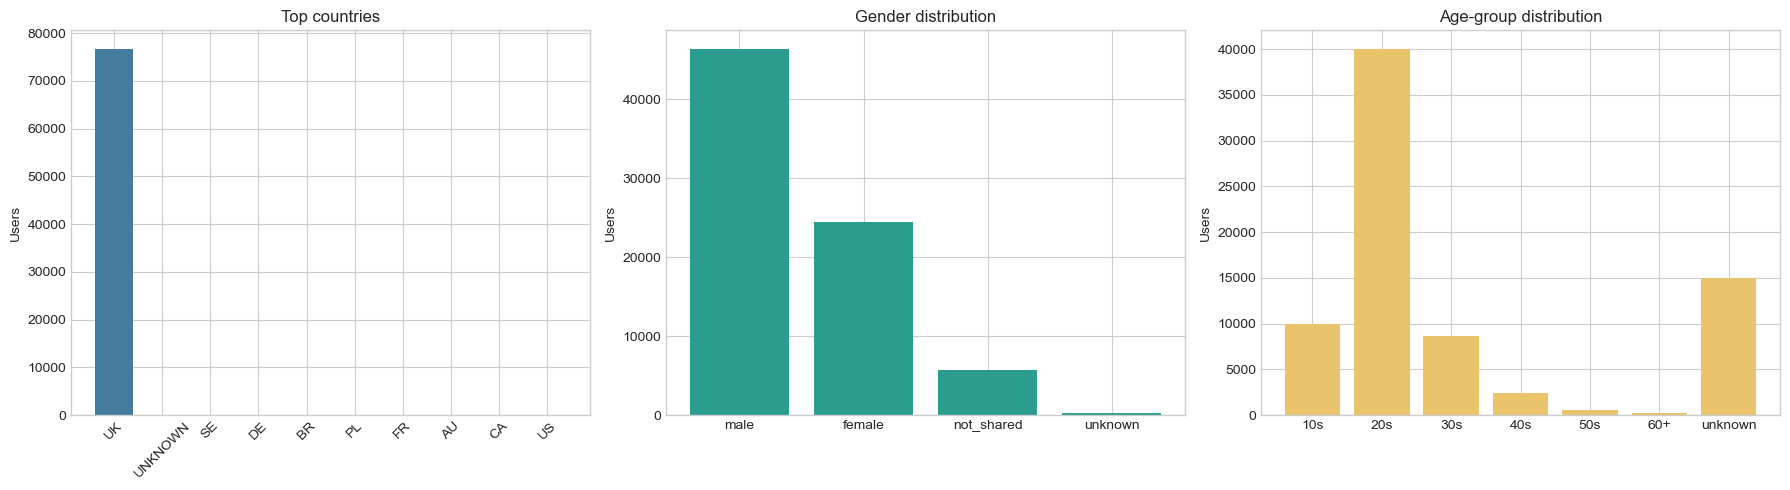

In [5]:
top_countries = users["country"].fillna("UNKNOWN").value_counts().head(10)
gender_distribution = users["gender"].fillna("unknown").value_counts()
age_group_distribution = users["age_group"].fillna("unknown").value_counts().reindex(
    ["10s", "20s", "30s", "40s", "50s", "60+", "unknown"],
    fill_value=0,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(top_countries.index, top_countries.values, color="#457b9d")
axes[0].set_title("Top countries")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(gender_distribution.index, gender_distribution.values, color="#2a9d8f")
axes[1].set_title("Gender distribution")
axes[1].set_ylabel("Users")

axes[2].bar(age_group_distribution.index, age_group_distribution.values, color="#e9c46a")
axes[2].set_title("Age-group distribution")
axes[2].set_ylabel("Users")

plt.tight_layout()
plt.show()

The demographic distributions show that the dataset is heavily concentrated in the UK and that younger age groups dominate the user base. This matters for the final project because age group is likely to be a stronger discriminating filter than country within the present data.

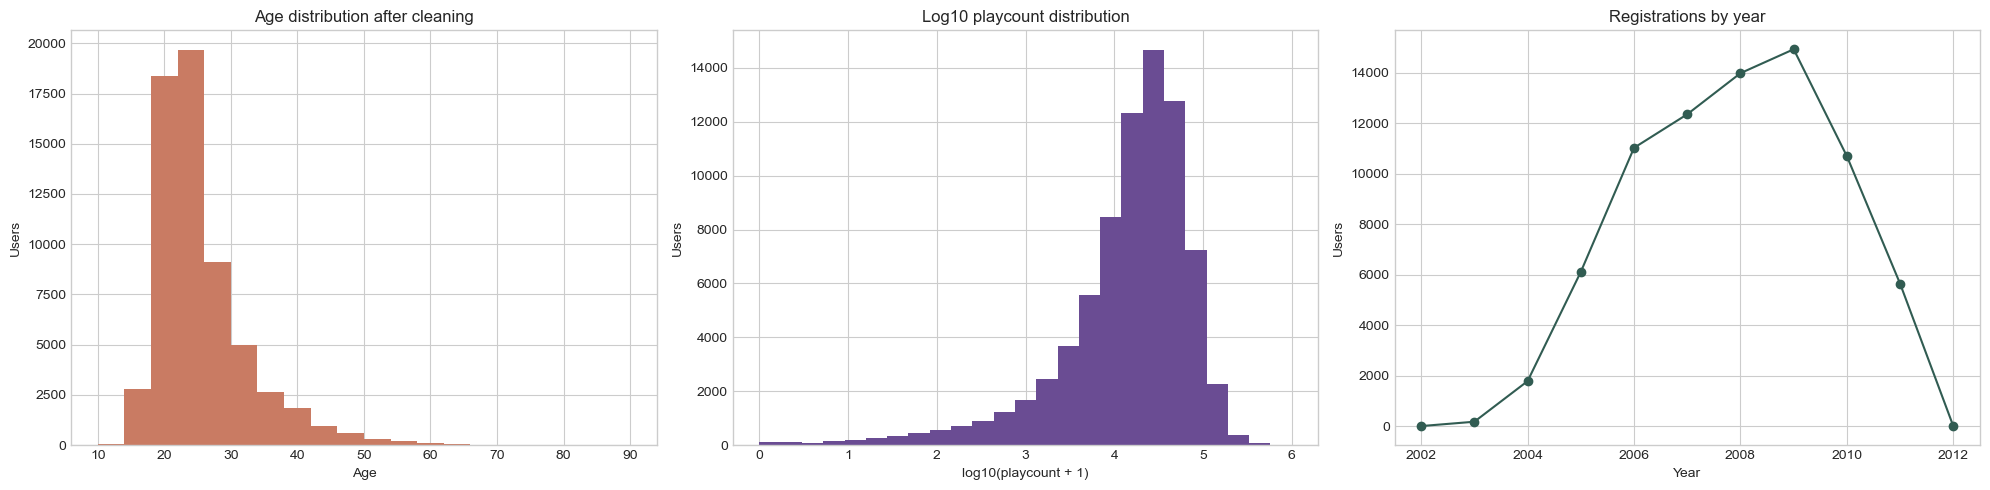

In [6]:
registrations_by_year = (
    users["registered_at"]
    .dt.year
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

playcount_non_missing = users["playcount"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(users["age_clean"].dropna(), bins=20, color="#c97b63")
axes[0].set_title("Age distribution after cleaning")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Users")

axes[1].hist(np.log10(playcount_non_missing + 1), bins=25, color="#6a4c93")
axes[1].set_title("Log10 playcount distribution")
axes[1].set_xlabel("log10(playcount + 1)")
axes[1].set_ylabel("Users")

axes[2].plot(registrations_by_year.index, registrations_by_year.values, marker="o", color="#315c52")
axes[2].set_title("Registrations by year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Users")

plt.tight_layout()
plt.show()

These plots give additional context to the user base. The cleaned age distribution looks plausible, playcount is highly skewed, and the registration timeline shows how the network accumulated over time.

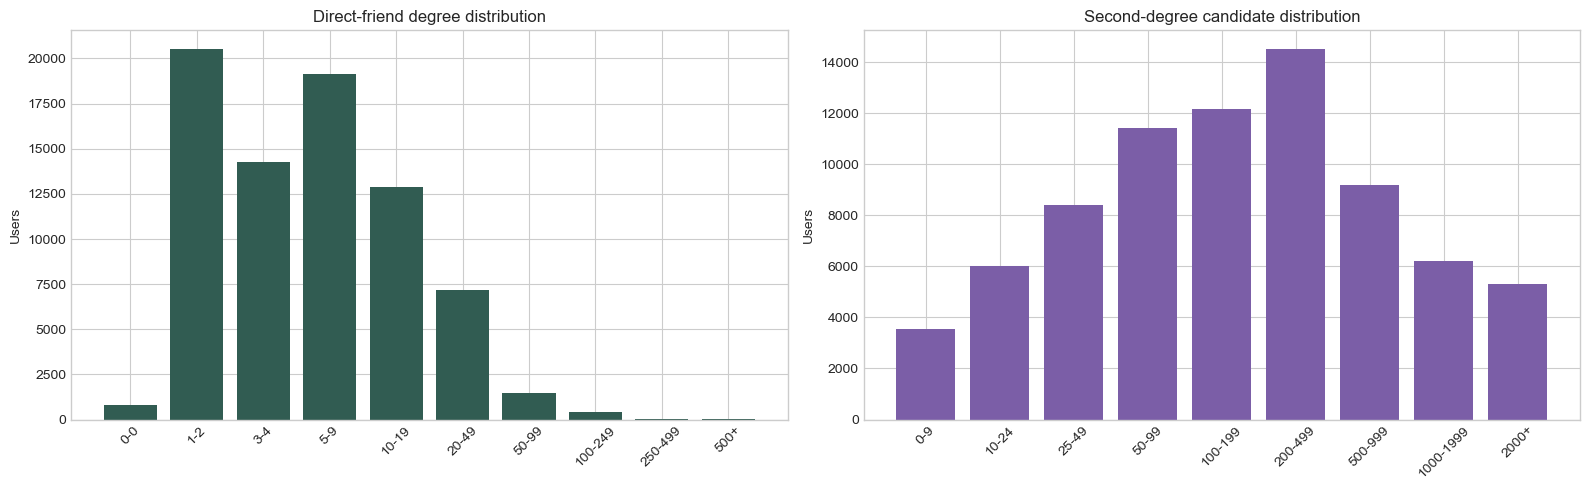

,user_id,degree,country,age_group
5902,5909,2013,UK,10s
51337,51398,1643,UK,20s
41610,41661,1554,UK,20s
46195,46248,1034,UK,40s
70310,70389,924,UK,<NA>
12351,12367,906,UK,50s
50561,50619,801,UK,<NA>
40002,40052,727,UK,<NA>
66358,66434,685,UK,<NA>
3705,3710,618,UK,<NA>


In [7]:
degree_hist = pd.DataFrame(summary["charts"]["degree_histogram"])
second_hist = pd.DataFrame(summary["charts"]["second_degree_histogram"])
top_degree_users = users[["user_id", "degree", "country", "age_group"]].sort_values(
    "degree", ascending=False
).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(degree_hist["label"], degree_hist["value"], color="#315c52")
axes[0].set_title("Direct-friend degree distribution")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(second_hist["label"], second_hist["value"], color="#7b5ea7")
axes[1].set_title("Second-degree candidate distribution")
axes[1].set_ylabel("Users")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(top_degree_users)

The network plots are the clearest empirical support for the final visualisation. The second-degree layer expands much more quickly than the first-degree layer, which means the value of the network really does lie one hop beyond direct friends.

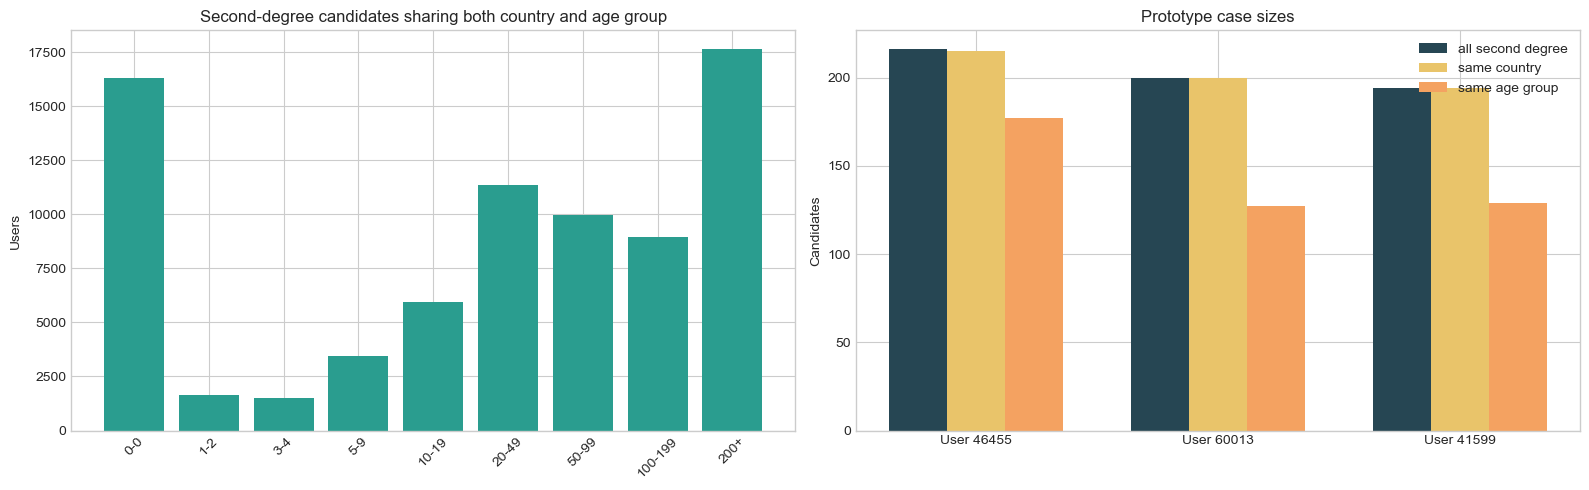

,label,direct_friends,second_degree_count,same_country_second_degree,same_age_group_second_degree,same_both_second_degree,visible_second_degree_count
0,User 46455,11,216,215,177,176,16
1,User 60013,14,200,200,127,127,16
2,User 41599,15,194,194,129,129,16


,ego_user,id,label,country,age_group,degree,mutual_friends,mutual_friend_ids,same_country,same_age_group,shared_attribute_count,score
0,46455,67974,User 67974,UK,20s,24,4,"[4801, 38375, 59703, 69346]",True,True,2,10
1,46455,44702,User 44702,UK,20s,78,2,"[36663, 54423]",True,True,2,6
2,46455,26989,User 26989,UK,20s,12,2,"[46963, 54423]",True,True,2,6
3,46455,43687,User 43687,UK,20s,10,2,"[46963, 54423]",True,True,2,6
4,46455,73750,User 73750,UK,20s,6,2,"[46963, 54423]",True,True,2,6
5,46455,51398,User 51398,UK,20s,1643,1,[69346],True,True,2,4
6,46455,3670,User 3670,UK,20s,310,1,[36663],True,True,2,4
7,46455,58786,User 58786,UK,20s,252,1,[46963],True,True,2,4
8,60013,10639,User 10639,UK,10s,199,5,"[9724, 19785, 50313, 58345, 61485]",True,True,2,12
9,60013,47859,User 47859,UK,10s,74,3,"[9724, 19785, 50313]",True,True,2,8


In [8]:
shared_hist = pd.DataFrame(summary["charts"]["shared_attribute_histogram"])
case_sizes = pd.DataFrame(summary["charts"]["prototype_case_sizes"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(shared_hist["label"], shared_hist["value"], color="#2a9d8f")
axes[0].set_title("Second-degree candidates sharing both country and age group")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=45)

x = np.arange(len(case_sizes))
width = 0.24

axes[1].bar(x - width, case_sizes["second_degree_count"], width=width, color="#264653", label="all second degree")
axes[1].bar(x, case_sizes["same_country_second_degree"], width=width, color="#e9c46a", label="same country")
axes[1].bar(x + width, case_sizes["same_age_group_second_degree"], width=width, color="#f4a261", label="same age group")
axes[1].set_xticks(x)
axes[1].set_xticklabels(case_sizes["label"])
axes[1].set_title("Prototype case sizes")
axes[1].set_ylabel("Candidates")
axes[1].legend()

plt.tight_layout()
plt.show()

prototype_cases = summary["prototype"]["cases"]
example_tables = []
for case in prototype_cases:
    candidate_table = pd.DataFrame(case["candidates"]).sort_values(
        ["shared_attribute_count", "mutual_friends", "degree"],
        ascending=[False, False, False],
    ).head(8)
    candidate_table.insert(0, "ego_user", case["user"]["id"])
    example_tables.append(candidate_table)

display(case_sizes)
display(pd.concat(example_tables, ignore_index=True))

This analysis turns the graph from a structural object into a meaningful social story. Not every friend-of-a-friend is equally relevant. Filtering by the supported shared attributes produces a smaller set of reachable candidates that are more socially plausible and more useful for the final interaction design.

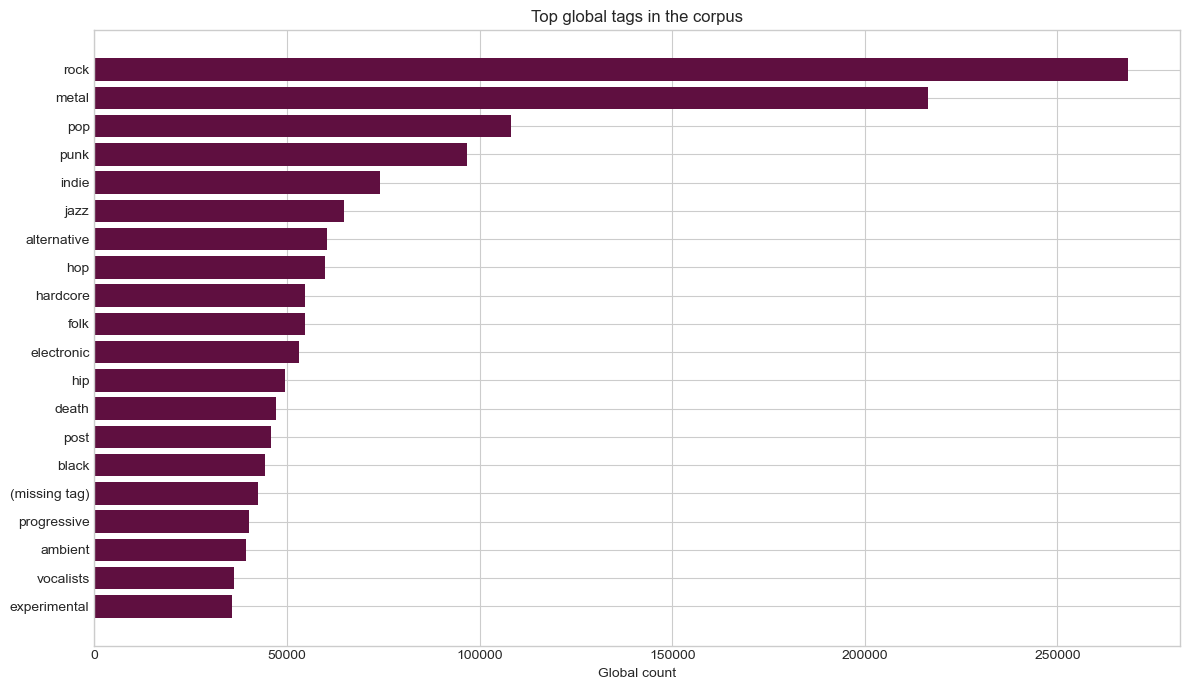

,tag_label,global_count
0,rock,268423
1,metal,216434
2,pop,108098
3,punk,96597
4,indie,74154
5,jazz,64667
6,alternative,60347
7,hop,59829
8,hardcore,54764
9,folk,54534


In [9]:
top_global_tags = tags.sort_values("global_count", ascending=False).head(20).copy()
top_global_tags["tag_label"] = top_global_tags["tag"].fillna("(missing tag)")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_global_tags["tag_label"][::-1], top_global_tags["global_count"][::-1], color="#5f0f40")
ax.set_title("Top global tags in the corpus")
ax.set_xlabel("Global count")
plt.tight_layout()
plt.show()

display(top_global_tags[["tag_label", "global_count"]].head(20))

The tag metadata still matters as supporting context. It shows that the broader Last.fm environment contains a rich musical vocabulary, which supports the original project vision around music taste. At the same time, this is not the same as computing music taste per user, so it should be treated as contextual evidence rather than as a substitute for missing user-level listening data.

### Interpretation

The exploratory analysis supports the project direction strongly. After preprocessing, the dataset remains large, usable, and structurally rich. The friendship graph is reliable once deduplicated, the demographic fields are usable after cleaning, and the second-degree layer is much larger than the first-degree layer for the typical user.

This confirms the central idea of the project: the most interesting opportunity is not only in direct friendships, but in the friends-of-friends layer. The data also shows that filtering by supported shared attributes such as age group and country makes that second-degree space more meaningful.

Music taste remains part of the project concept and must stay in the broader narrative, but in this milestone it can only be treated honestly as a future extension unless user-level listening data is added.

## Related Work

### What Others Have Already Done with the Data

The LastFM dataset family is one of the most widely used in academic research, but almost exclusively for a single purpose: music recommendation systems. LastFM datasets have become benchmark tools for algorithms designed around implicit feedback signals, such as Alternating Least Squares (ALS), Bayesian Personalised Ranking (BPR), and LightGCN, where play counts serve as proxies for user preference. In other words, prior work treats the dataset as an input to a recommendation engine, asking "what should this user listen to next?”

Ref: Stanford Large Network Dataset Collection

A typical example is using the dataset to build a music recommender that incorporates user metadata, age, gender, and country, as additional features for more advanced models. The friendship graph, when used at all, is treated as a side feature to improve recommendation accuracy through social influence modelling, not as the primary subject of exploration.

Ref: ResearchGate

On the broader LastFM network specifically (not the UK subset), it has been used in heterogeneous graph embedding research, treating users, artists, and tags as three distinct node types and studying link prediction between them. Again, the focus is on machine learning performance benchmarks, not human storytelling.

Ref: NetworkRepository

### Why Our Approach is Original

1. **The network as the story, not the background.** Previous work uses the friendship graph as a feature to improve recommendations. We put the graph front and centre, the connections between people are the visualisation, not a means to an end.

2. **Attribute-driven 2nd degree exploration with AND/OR logic.** Existing visualisations of 2nd degree friend networks have acknowledged the challenge of making friends-of-friends connections readable, noting that 1st degree connections tend to dominate visually. Our approach addresses this directly by filtering the 2nd degree layer by shared attributes.

Ref: Stanford Large Network Dataset Collection

3. **Human narrative over analytical output.** Rather than a researcher's tool, this is designed as an experience for a general audience, the story of how close we already are to people we haven't met.

### Sources of Inspiration

Our main inspiration is a visualization of the digital humanities academic community’s social network graph made by Martin Grandjean in his project called “Digital Humanities on Twitter, a small-world?”. Each node represents a person and the color of the node represents the amount of followers that specific account has. Grandjean also added some labels to clusters of nodes or noteworthy individual nodes according to their importance or interest.